In [1]:
# ── Cell 1: pip installs + imports ──────────────────────────────────────────
# Avoid pinning datasets==2.21.0 on Kaggle: it downgrades fsspec/dill and
# triggers resolver conflicts with Kaggle's preinstalled cloud packages.
%pip install -q --no-deps datasets transformers huggingface_hub
# torch / torchvision are pre-installed on Kaggle — do NOT reinstall them;
# forcing a specific index-url overwrites the kernel's GPU-compatible build.
%pip install -q --no-deps ipywidgets matplotlib scikit-learn

import os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from typing import Optional
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from transformers import BertModel, BertTokenizer
from datasets import load_dataset as hf_load
from huggingface_hub import login

# ── HuggingFace auth: Kaggle Secrets ────────────────────────────────────────
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
login(token=secret_value_0)
print("HuggingFace login: OK")

print("torch :", torch.__version__)
print("cuda  :", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
HuggingFace login: OK
torch : 2.10.0+cu128
cuda  : True
device: cuda


In [2]:
# ── Cell 2: ModelConfig, TrainingConfig ──────────────────────────────────────
class ModelConfig:
    n_embd     = 768
    n_layer    = 12
    n_head     = 12
    block_size = 512
    vocab_size = 30522
    eps        = 1e-12
    embd_pdrop = 0.1
    num_labels = 5      # 1-star … 5-star

class TrainingConfig:
    resid_pdrop = 0.1
    attn_pdrop  = 0.1

In [3]:
# ── Cell 3: model classes (GELU → LayerNorm → BertEmbeddings →
#            MultiHeadAttention → FeedForward → TransformerBlock →
#            BertPooler → Bert) ───────────────────────────────────────────────

# ── model/gelu.py ─────────────────────────────────────────────────────────────
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x**3)))


# ── model/layernorm.py ────────────────────────────────────────────────────────
class LayerNorm(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(config.n_embd))
        self.beta  = nn.Parameter(torch.zeros(config.n_embd))
        self.eps   = config.eps

    def forward(self, x):
        mean  = x.mean(-1, keepdim=True)
        var   = x.var(-1, keepdim=True, unbiased=False)
        return self.gamma * (x - mean) / (var + self.eps).sqrt() + self.beta


# ── model/BertEmbeddings.py ───────────────────────────────────────────────────
class BertEmbeddings(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.word_embeddings        = nn.Embedding(config.vocab_size,  config.n_embd)
        self.position_embeddings    = nn.Embedding(config.block_size,  config.n_embd)
        self.token_type_embeddings  = nn.Embedding(2,                  config.n_embd)
        self.LayerNorm              = nn.LayerNorm(config.n_embd, eps=config.eps)
        self.dropout                = nn.Dropout(config.embd_pdrop)

    def forward(self, input_ids: Tensor,
                token_type_ids: Optional[Tensor] = None,
                position_ids:   Optional[Tensor] = None) -> Tensor:
        T = input_ids.shape[1]
        if position_ids is None:
            position_ids = torch.arange(T, device=input_ids.device).unsqueeze(0)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        hidden = (self.word_embeddings(input_ids)
                  + self.position_embeddings(position_ids)
                  + self.token_type_embeddings(token_type_ids))
        return self.dropout(self.LayerNorm(hidden))


# ── model/attention.py ────────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, config: ModelConfig, train_config: TrainingConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_embd    = config.n_embd
        self.num_heads = config.n_head
        self.head_dim  = config.n_embd // config.n_head

        self.W_Q           = nn.Linear(config.n_embd, config.n_embd)
        self.W_K           = nn.Linear(config.n_embd, config.n_embd)
        self.W_V           = nn.Linear(config.n_embd, config.n_embd)
        self.final_linear  = nn.Linear(config.n_embd, config.n_embd)
        self.attn_dropout  = nn.Dropout(train_config.attn_pdrop)
        self.resid_dropout = nn.Dropout(train_config.resid_pdrop)

    def _split(self, x: Tensor) -> Tensor:
        B, T, _ = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    def _merge(self, x: Tensor) -> Tensor:
        B, H, T, D = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, self.n_embd)

    def forward(self, x: Tensor, attention_mask: Optional[Tensor] = None) -> Tensor:
        q = self._split(self.W_Q(x))
        k = self._split(self.W_K(x))
        v = self._split(self.W_V(x))

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if attention_mask is not None:
            scores = scores.masked_fill(
                attention_mask[:, None, None, :] == 0, float('-inf')
            )

        probs = self.attn_dropout(F.softmax(scores, dim=-1))
        out   = self.resid_dropout(self.final_linear(self._merge(torch.matmul(probs, v))))
        return out


# ── model/feedforward.py ──────────────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, config: ModelConfig, train_config: TrainingConfig):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.dropout = nn.Dropout(train_config.resid_pdrop)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


# ── model/block.py ────────────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, modelconfig: ModelConfig, trainconfig: TrainingConfig):
        super().__init__()
        self.ln1  = LayerNorm(modelconfig)
        self.attn = MultiHeadAttention(modelconfig, trainconfig)
        self.ln2  = LayerNorm(modelconfig)
        self.mlp  = FeedForward(modelconfig, trainconfig)

    def forward(self, x, attention_mask=None):
        x = self.ln1(x + self.attn(x, attention_mask))   # post-LN
        x = self.ln2(x + self.mlp(x))
        return x


# ── model/BertPooler.py ───────────────────────────────────────────────────────
class BertPooler(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.dense      = nn.Linear(config.n_embd, config.n_embd)
        self.activation = nn.Tanh()

    def forward(self, hidden_states):
        return self.activation(self.dense(hidden_states[:, 0, :]))   # [CLS]


# ── model/Bert.py ─────────────────────────────────────────────────────────────
class Bert(nn.Module):
    def __init__(self, modelconfig: ModelConfig, trainingconfig: TrainingConfig):
        super().__init__()
        self.embeddings = BertEmbeddings(modelconfig)
        self.h          = nn.ModuleList([
            TransformerBlock(modelconfig, trainingconfig)
            for _ in range(modelconfig.n_layer)
        ])
        self.pooler     = BertPooler(modelconfig)
        self.classifier = nn.Linear(modelconfig.n_embd, modelconfig.num_labels)
        self.config     = modelconfig
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        x = self.embeddings(input_ids, token_type_ids)
        for block in self.h:
            x = block(x, attention_mask)
        return self.classifier(self.pooler(x))


print("All model classes defined.")

All model classes defined.


In [4]:
# ── Cell 4: build remapping dict, load pretrained bert-base-uncased weights ───

def build_hf_to_custom_map(n_layers: int = 12) -> dict:
    m = {}

    # embeddings — nn.LayerNorm uses weight/bias, names match HF exactly
    for key in (
        "embeddings.word_embeddings.weight",
        "embeddings.position_embeddings.weight",
        "embeddings.token_type_embeddings.weight",
        "embeddings.LayerNorm.weight",
        "embeddings.LayerNorm.bias",
    ):
        m[key] = key

    for i in range(n_layers):
        hf = f"encoder.layer.{i}"
        us = f"h.{i}"

        m[f"{hf}.attention.self.query.weight"]        = f"{us}.attn.W_Q.weight"
        m[f"{hf}.attention.self.query.bias"]          = f"{us}.attn.W_Q.bias"
        m[f"{hf}.attention.self.key.weight"]          = f"{us}.attn.W_K.weight"
        m[f"{hf}.attention.self.key.bias"]            = f"{us}.attn.W_K.bias"
        m[f"{hf}.attention.self.value.weight"]        = f"{us}.attn.W_V.weight"
        m[f"{hf}.attention.self.value.bias"]          = f"{us}.attn.W_V.bias"
        m[f"{hf}.attention.output.dense.weight"]      = f"{us}.attn.final_linear.weight"
        m[f"{hf}.attention.output.dense.bias"]        = f"{us}.attn.final_linear.bias"
        # custom LayerNorm stores gamma/beta (not weight/bias like nn.LayerNorm)
        m[f"{hf}.attention.output.LayerNorm.weight"]  = f"{us}.ln1.gamma"
        m[f"{hf}.attention.output.LayerNorm.bias"]    = f"{us}.ln1.beta"
        m[f"{hf}.intermediate.dense.weight"]          = f"{us}.mlp.c_fc.weight"
        m[f"{hf}.intermediate.dense.bias"]            = f"{us}.mlp.c_fc.bias"
        m[f"{hf}.output.dense.weight"]                = f"{us}.mlp.c_proj.weight"
        m[f"{hf}.output.dense.bias"]                  = f"{us}.mlp.c_proj.bias"
        m[f"{hf}.output.LayerNorm.weight"]            = f"{us}.ln2.gamma"
        m[f"{hf}.output.LayerNorm.bias"]              = f"{us}.ln2.beta"

    m["pooler.dense.weight"] = "pooler.dense.weight"
    m["pooler.dense.bias"]   = "pooler.dense.bias"
    return m


def load_pretrained_weights(model: Bert, hf_sd: dict, mapping: dict):
    our_sd  = model.state_dict()
    loaded, skipped = [], []

    with torch.no_grad():
        for hf_key, our_key in mapping.items():
            if hf_key not in hf_sd or our_key not in our_sd:
                skipped.append((hf_key, our_key))
                continue
            assert hf_sd[hf_key].shape == our_sd[our_key].shape, (
                f"Shape mismatch  HF:{hf_key} {tuple(hf_sd[hf_key].shape)} "
                f"vs ours:{our_key} {tuple(our_sd[our_key].shape)}"
            )
            our_sd[our_key].copy_(hf_sd[hf_key])
            loaded.append(our_key)

    model.load_state_dict(our_sd)
    print(f"Loaded  : {len(loaded)}")
    print(f"Skipped : {len(skipped)}")
    return loaded, skipped


# ── instantiate + load ────────────────────────────────────────────────────────
cfg       = ModelConfig()
train_cfg = TrainingConfig()
model     = Bert(cfg, train_cfg)

print("Downloading bert-base-uncased …")
hf_model = BertModel.from_pretrained("bert-base-uncased")
hf_sd    = hf_model.state_dict()
del hf_model   # free CPU RAM

mapping = build_hf_to_custom_map(n_layers=cfg.n_layer)
loaded, _ = load_pretrained_weights(model, hf_sd, mapping)
print(f"{len(loaded)} / {len(mapping)} weights loaded")
model = model.to(DEVICE)

# ── sanity forward pass ───────────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
enc = tokenizer("The battery life is excellent.", return_tensors="pt")
model.eval()
with torch.no_grad():
    logits = model(enc["input_ids"].to(DEVICE),
                   attention_mask=enc["attention_mask"].to(DEVICE))
print("logits shape:", logits.shape)   # (1, 5)
assert logits.shape == (1, 5), f"Expected (1,5), got {logits.shape}"
print("forward pass OK")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded  : 199
Skipped : 0
199 / 199 weights loaded


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

logits shape: torch.Size([1, 5])
forward pass OK


In [5]:
# ── Cell 5: AmazonReview Dataset + DataLoaders ───────────────────────────────
# dataset/AmazonReview.py (inherits torch Dataset, not HF Dataset)

class AmazonReview(Dataset):
    """Wraps a HuggingFace dataset split for 1-5 star classification."""
    def __init__(self, hf_dataset, tokenizer, max_length: int = 256):
        self.dataset    = hf_dataset
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item   = self.dataset[idx]
        text   = item.get('text') or ''        # guard None text
        rating = item.get('rating')
        rating = rating if rating is not None else 3   # avoid `or` (rating==0.0 would fall through)
        label  = max(0, min(4, int(float(rating)) - 1))

        tokens = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      tokens['input_ids'].squeeze(0),
            'attention_mask': tokens['attention_mask'].squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long),
        }


# ── load ──────────────────────────────────────────────────────────────────────
# We use cogsci13/Amazon-Reviews-2023-Books-Review — a Parquet mirror of the
# McAuley-Lab/Amazon-Reviews-2023 'raw_review_Books' config. The original repo
# ships a loading script (Amazon-Reviews-2023.py), which datasets>=3.0 no longer
# supports; the mirror is script-free Parquet with the same schema (rating,
# title, text, asin, parent_asin, user_id, timestamp, helpful_vote, …).
# Kaggle T4/P100 GPU limit: 9 hours.  100 k rows ≈ 10 min streaming + fits RAM.
# Raise to 500_000–1_500_000 only if you have extra quota / time to spare.
# The streamed sample is saved locally and pushed to HF Hub so it survives
# Kaggle session auto-ends. Reruns try local cache -> HF Hub cache -> stream.
from itertools import islice
import datasets as _ds
import shutil

DATASET_REPO_ID = "cogsci13/Amazon-Reviews-2023-Books-Review"
DATASET_SPLIT   = "full"           # this mirror exposes only the "full" split
DATASET_LABEL   = "books_review"   # used in cache name only
N_SAMPLES = 1_500_000
HF_DATASET_CACHE_REPO_ID = "AgentPhoenix7/SLM-project-dataset-cache"
CACHE_ROOT = "/kaggle/working/data" if os.path.exists("/kaggle/working") else "data"
DATASET_CACHE_NAME = f"amazon_reviews_2023_{DATASET_LABEL}_{N_SAMPLES}"
DATASET_CACHE_DIR = os.path.join(CACHE_ROOT, DATASET_CACHE_NAME)

def load_dataset_cache():
    if os.path.exists(DATASET_CACHE_DIR):
        print(f"Loading local dataset cache from {DATASET_CACHE_DIR}")
        return _ds.load_from_disk(DATASET_CACHE_DIR)

    if HF_DATASET_CACHE_REPO_ID:
        try:
            from huggingface_hub import snapshot_download
            print(f"Downloading dataset cache from HF Hub: {HF_DATASET_CACHE_REPO_ID}")
            os.makedirs(CACHE_ROOT, exist_ok=True)
            snapshot_download(
                repo_id=HF_DATASET_CACHE_REPO_ID,
                repo_type="dataset",
                allow_patterns=f"{DATASET_CACHE_NAME}/**",
                local_dir=CACHE_ROOT,
            )
            if os.path.exists(DATASET_CACHE_DIR):
                return _ds.load_from_disk(DATASET_CACHE_DIR)
            print("HF Hub dataset cache path not found after download; will stream source dataset.")
        except Exception as e:
            print(f"HF Hub dataset cache unavailable: {e}")

    return None

def save_dataset_cache(dataset):
    os.makedirs(CACHE_ROOT, exist_ok=True)
    tmp_cache_dir = DATASET_CACHE_DIR + ".tmp"
    if os.path.exists(tmp_cache_dir):
        shutil.rmtree(tmp_cache_dir)
    dataset.save_to_disk(tmp_cache_dir)
    os.rename(tmp_cache_dir, DATASET_CACHE_DIR)
    print(f"Saved local dataset cache to {DATASET_CACHE_DIR}")

    if HF_DATASET_CACHE_REPO_ID:
        try:
            from huggingface_hub import HfApi
            api = HfApi()
            api.create_repo(HF_DATASET_CACHE_REPO_ID, repo_type="dataset", exist_ok=True, private=True)
            api.upload_folder(
                folder_path=DATASET_CACHE_DIR,
                path_in_repo=DATASET_CACHE_NAME,
                repo_id=HF_DATASET_CACHE_REPO_ID,
                repo_type="dataset",
            )
            print(f"Uploaded dataset cache to HF Hub: {HF_DATASET_CACHE_REPO_ID}/{DATASET_CACHE_NAME}")
        except Exception as e:
            print(f"HF Hub dataset cache upload failed (non-fatal): {e}")

raw = load_dataset_cache()
if raw is None:
    print(f"Streaming {N_SAMPLES:,} samples from {DATASET_REPO_ID}/{DATASET_SPLIT} …")
    stream = hf_load(
        DATASET_REPO_ID,
        split=DATASET_SPLIT,
        streaming=True,
    )
    raw = _ds.Dataset.from_list(list(islice(stream, N_SAMPLES)))
    save_dataset_cache(raw)
print(f"Total samples : {len(raw):,}")
print("Columns       :", raw.column_names)

splits   = raw.train_test_split(test_size=0.1, seed=42)
train_ds = AmazonReview(splits["train"], tokenizer)
val_ds   = AmazonReview(splits["test"],  tokenizer)

BATCH_SIZE   = 32
# num_workers=2 works on Kaggle; use 0 if you hit multiprocessing errors
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")

batch = next(iter(train_loader))
print("Sample batch  :", {k: tuple(v.shape) for k, v in batch.items()})

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Total samples : 1,500,000
Columns       : ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Train batches : 42,188
Val   batches : 4,688
Sample batch  : {'input_ids': (32, 256), 'attention_mask': (32, 256), 'label': (32,)}


In [6]:
# ── Cell 6: training infrastructure ──────────────────────────────────────────
import glob as _glob

# ── optimizer ────────────────────────────────────────────────────────────────
def configure_optimizer(model: Bert, lr: float = 2e-5, weight_decay: float = 0.01):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if "bias" in name or "ln1" in name or "ln2" in name or "LayerNorm" in name:
            no_decay.append(param)
        else:
            decay.append(param)
    return AdamW(
        [{"params": decay,    "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=lr, betas=(0.9, 0.999), eps=1e-8,
    )


# ── scheduler ────────────────────────────────────────────────────────────────
class CosineScheduler:
    def __init__(self, optimizer, warmup_steps: int, total_steps: int,
                 max_lr: float, min_lr: float):
        self.optimizer    = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.max_lr       = max_lr
        self.min_lr       = min_lr
        self.current_step = 0

    def get_lr(self) -> float:
        if self.current_step >= self.total_steps:
            return self.min_lr
        if self.current_step < self.warmup_steps:
            return self.max_lr * self.current_step / self.warmup_steps
        progress = (self.current_step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
        return self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))

    def step(self):
        for pg in self.optimizer.param_groups:
            pg['lr'] = self.get_lr()
        self.current_step += 1

    def state_dict(self):
        return {k: v for k, v in self.__dict__.items() if k != 'optimizer'}

    def load_state_dict(self, sd):
        for k, v in sd.items():
            setattr(self, k, v)


# ── loss ──────────────────────────────────────────────────────────────────────
def compute_loss(logits: Tensor, labels: Tensor,
                 label_smoothing: float = 0.0) -> Tensor:
    return F.cross_entropy(logits, labels, label_smoothing=label_smoothing)


# ── trainer ───────────────────────────────────────────────────────────────────
# /kaggle/working is wiped on session end, so local checkpoints are ephemeral.
# Every checkpoint is pushed to HF Hub (hf_repo_id) — that is the only durable
# store. CKPT_EVERY controls both the local save interval and the hub upload
# interval, so don't set it too low for large datasets (each upload is ~450 MB).
# Good rule of thumb: CKPT_EVERY ≈ 10-20 min of GPU time.
#   100 k samples, batch 32, accum 2  → ~1 400 steps/epoch → 250 is fine
#   500 k samples                     → ~7 000 steps/epoch → use 500-1 000
CKPT_EVERY      = 250
MAX_VAL_BATCHES = 200    # cap mid-epoch validation (~6 400 samples)

class Trainer:
    def __init__(self, model, train_loader: DataLoader, val_loader: DataLoader,
                 scheduler: CosineScheduler, train_config: TrainingConfig,
                 optimizer=None, loss_fn=None,
                 device: str = "cpu", use_amp: bool = False,
                 accumulation_steps: int = 1,
                 checkpoint_dir: str = "./checkpoints",
                 hf_repo_id: str = None):
        self.model              = model
        self.train_loader       = train_loader
        self.val_loader         = val_loader
        self.optimizer          = optimizer
        self.loss_fn            = loss_fn or compute_loss
        self.scheduler          = scheduler
        self.train_config       = train_config
        self.device             = device
        self.use_amp            = use_amp and device != 'cpu'
        self.scaler             = GradScaler() if self.use_amp else None
        self.accumulation_steps = accumulation_steps
        self.checkpoint_dir     = checkpoint_dir
        self.hf_repo_id         = hf_repo_id
        self.global_step        = 0
        self.best_val_loss      = float('inf')

        os.makedirs(checkpoint_dir, exist_ok=True)

        if not hf_repo_id:
            print("WARNING: hf_repo_id is not set — checkpoints will NOT survive "
                  "a Kaggle session end. Set HF_REPO_ID in Cell 7 to enable "
                  "HF Hub backup.", flush=True)

        if torch.cuda.device_count() > 1:
            self.model = torch.nn.DataParallel(self.model)

    # ── single epoch ─────────────────────────────────────────────────────────
    def train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0
        step = -1   # so the post-loop residual check is safe even if the loader is empty

        for step, batch in enumerate(self.train_loader):
            input_ids      = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels         = batch['label'].to(self.device)

            if self.use_amp:
                with autocast(device_type='cuda'):
                    logits = self.model(input_ids, attention_mask=attention_mask)
                    loss   = self.loss_fn(logits, labels) / self.accumulation_steps
                self.scaler.scale(loss).backward()
            else:
                logits = self.model(input_ids, attention_mask=attention_mask)
                loss   = self.loss_fn(logits, labels) / self.accumulation_steps
                loss.backward()

            if (step + 1) % self.accumulation_steps == 0:
                if self.use_amp:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                self.optimizer.zero_grad()
                self.scheduler.step()
                self.global_step += 1

                if self.global_step % CKPT_EVERY == 0:
                    metrics = self.validate(max_batches=MAX_VAL_BATCHES)
                    self.model.train()
                    tag = f"step_{self.global_step}"
                    print(f"[step {self.global_step}] "
                          f"val_loss={metrics['val_loss']:.4f}  "
                          f"val_acc={metrics['accuracy']:.4f}")

                    self.save_checkpoint(
                        epoch, metrics['val_loss'],
                        os.path.join(self.checkpoint_dir, f"{tag}.pt"),
                        checkpoint_type='step',
                    )
                    self._prune_step_checkpoints(keep=3)

                    if metrics['val_loss'] < self.best_val_loss:
                        self.best_val_loss = metrics['val_loss']
                        self.save_checkpoint(
                            epoch, metrics['val_loss'],
                            os.path.join(self.checkpoint_dir, "best.pt"),
                            checkpoint_type='step',
                        )
                        print(f"  ** new best at step {self.global_step}: "
                              f"val_loss={self.best_val_loss:.4f} **")

            total_loss += loss.item() * self.accumulation_steps

            if step % 100 == 0:
                lr = self.optimizer.param_groups[0]['lr']
                print(f"  epoch {epoch}  step {step:>6d}  "
                      f"loss {loss.item() * self.accumulation_steps:.4f}  lr {lr:.2e}")

        # Discard residual grads from a partial accumulation window so they
        # don't bleed into the first step of the next epoch.
        if (step + 1) % self.accumulation_steps != 0:
            self.optimizer.zero_grad()

        return total_loss / max(1, len(self.train_loader))

    # ── validation ───────────────────────────────────────────────────────────
    def validate(self, max_batches: int = None) -> dict:
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        n_batches = 0
        limit = max_batches or len(self.val_loader)
        print(f"  [validate] running up to {limit} batches …", flush=True)

        with torch.no_grad():
            for i, batch in enumerate(self.val_loader):
                if i >= limit:
                    break
                input_ids      = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels         = batch['label'].to(self.device)

                logits     = self.model(input_ids, attention_mask=attention_mask)
                total_loss += self.loss_fn(logits, labels).item()
                correct    += (logits.argmax(-1) == labels).sum().item()
                total      += labels.size(0)
                n_batches  += 1

        print(f"  [validate] done.", flush=True)
        return {
            'val_loss': total_loss / max(1, n_batches),
            'accuracy': correct / max(1, total),
        }

    # ── full training loop ────────────────────────────────────────────────────
    def train(self, num_epochs: int, start_epoch: int = 0) -> float:
        for epoch in range(start_epoch, num_epochs):
            print(f"\n{'='*60}  Epoch {epoch+1}/{num_epochs}  {'='*60}")
            train_loss = self.train_epoch(epoch)
            metrics    = self.validate()
            self.model.train()

            print(f"  [epoch {epoch+1} end]  "
                  f"train_loss={train_loss:.4f}  "
                  f"val_loss={metrics['val_loss']:.4f}  "
                  f"val_acc={metrics['accuracy']:.4f}")

            self.save_checkpoint(
                epoch, metrics['val_loss'],
                os.path.join(self.checkpoint_dir, f"epoch_{epoch+1}.pt"),
                checkpoint_type='epoch',
            )

            if metrics['val_loss'] < self.best_val_loss:
                self.best_val_loss = metrics['val_loss']
                self.save_checkpoint(
                    epoch, metrics['val_loss'],
                    os.path.join(self.checkpoint_dir, "best.pt"),
                    checkpoint_type='epoch',
                )
                print("  ** new best (epoch end) **")

        return self.best_val_loss

    # ── checkpointing ─────────────────────────────────────────────────────────
    def save_checkpoint(self, epoch, val_loss, path, checkpoint_type: str = 'step'):
        m = self.model.module if isinstance(self.model, torch.nn.DataParallel) else self.model
        state = {
            'epoch':                epoch,
            'global_step':          self.global_step,
            'checkpoint_type':      checkpoint_type,
            'model_state_dict':     m.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'val_loss':             val_loss,
            'best_val_loss':        self.best_val_loss,
        }
        torch.save(state, path)

        # last.pt = fixed-name alias to the most recent checkpoint.
        # Also the file that gets pushed to HF Hub (single overwritten blob,
        # keeps hub storage flat).
        last_path = os.path.join(self.checkpoint_dir, "last.pt")
        torch.save(state, last_path)

        # Always push to HF Hub — /kaggle/working is wiped on session end so
        # the hub copy is the only durable checkpoint.
        if self.hf_repo_id:
            self._push_to_hub(last_path)
            if os.path.basename(path) == "best.pt":
                self._push_to_hub(path, "checkpoints/best.pt")

    def _push_to_hub(self, local_path: str, repo_path: str = "checkpoints/last.pt"):
        """Overwrite checkpoints/last.pt in the HF Hub repo."""
        try:
            from huggingface_hub import HfApi
            api = HfApi()
            api.create_repo(self.hf_repo_id, repo_type="model",
                            exist_ok=True, private=True)
            api.upload_file(
                path_or_fileobj=local_path,
                path_in_repo=repo_path,
                repo_id=self.hf_repo_id,
                repo_type="model",
            )
            print(f"  [hub] ✓ {repo_path} → {self.hf_repo_id} "
                  f"(step {self.global_step})", flush=True)
        except Exception as e:
            print(f"  [hub] upload failed (non-fatal): {e}", flush=True)

    def _prune_step_checkpoints(self, keep: int = 3):
        step_ckpts = sorted(
            _glob.glob(os.path.join(self.checkpoint_dir, "step_*.pt"))
        )
        for old in step_ckpts[:-keep]:
            os.remove(old)

    def load_checkpoint(self, path) -> int:
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        m = self.model.module if isinstance(self.model, torch.nn.DataParallel) else self.model
        m.load_state_dict(ckpt['model_state_dict'])
        self.optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        self.scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        self.global_step   = ckpt.get('global_step', 0)
        self.best_val_loss = ckpt.get('best_val_loss', float('inf'))
        ckpt_type = ckpt.get('checkpoint_type', 'epoch')
        print(f"Resumed from {os.path.basename(path)}  "
              f"(epoch={ckpt['epoch']}, step={self.global_step}, "
              f"type={ckpt_type}, best_val_loss={self.best_val_loss:.4f})")
        # epoch checkpoint → training for that epoch completed → start epoch+1
        # step checkpoint  → session died mid-epoch → re-run from epoch start
        #   (DataLoader reshuffles, but model + optimizer state are correct)
        return ckpt['epoch'] + (1 if ckpt_type == 'epoch' else 0)


print("Training infrastructure defined.")
print(f"CKPT_EVERY = {CKPT_EVERY} optimizer steps  (local save + HF Hub push)")

Training infrastructure defined.
CKPT_EVERY = 250 optimizer steps  (local save + HF Hub push)


In [7]:
# ── Cell 7: run training ──────────────────────────────────────────────────────
CKPT_DIR   = "./checkpoints"
NUM_EPOCHS = 3

# ── REQUIRED for cross-session resume ─────────────────────────────────────────
# /kaggle/working is wiped when a Kaggle session ends (quota expiry, timeout,
# or manual stop).  The HF Hub repo below is the only durable checkpoint store.
#
# How to set up:
#   1. Create a Kaggle Secret named "HF_TOKEN" with your HF write-access token
#      (Add-ons → Secrets in the Kaggle notebook UI).
#   2. Set HF_REPO_ID to "<your-hf-username>/<any-repo-name>".
#      The repo is created automatically as private if it doesn't exist.
#
# To resume after a quota expiry:
#   - Just re-run all cells.  Cell 7 will download last.pt from the hub and
#     pick up from the right epoch automatically.
HF_REPO_ID = "AgentPhoenix7/SLM-project"   # e.g. "myusername/bert-amazon-ckpts"

if HF_REPO_ID is None:
    print("⚠  HF_REPO_ID is not set.  Checkpoints will be lost on session end.")
    print("   Set HF_REPO_ID above to enable cross-session resume.")

# ÷ accumulation_steps; parens force per-epoch division so the result matches
# the actual optimizer-step count (NUM_EPOCHS × steps_per_epoch).
TOTAL_STEPS  = NUM_EPOCHS * (len(train_loader) // 2)
WARMUP_STEPS = int(0.06 * TOTAL_STEPS)
MAX_LR, MIN_LR = 2e-5, 1e-6

optimizer = configure_optimizer(model, lr=MAX_LR)
scheduler = CosineScheduler(optimizer, WARMUP_STEPS, TOTAL_STEPS, MAX_LR, MIN_LR)
trainer   = Trainer(
    model, train_loader, val_loader, scheduler, train_cfg,
    optimizer=optimizer, device=DEVICE, use_amp=True, accumulation_steps=2,
    checkpoint_dir=CKPT_DIR, hf_repo_id=HF_REPO_ID,
)

# ── resume logic ──────────────────────────────────────────────────────────────
# Priority: HF Hub  →  local last.pt (same session)  →  local epoch_*.pt  →  fresh
import glob

start_epoch = 0
resumed     = False

# 1. Try HF Hub first — the only store that survives session end
if HF_REPO_ID and not resumed:
    try:
        from huggingface_hub import hf_hub_download
        hub_path = hf_hub_download(
            repo_id=HF_REPO_ID,
            filename="checkpoints/last.pt",
            repo_type="model",
            force_download=True,   # always pull the latest version
        )
        start_epoch = trainer.load_checkpoint(hub_path)
        print(f"Resumed from HF Hub ({HF_REPO_ID}), start_epoch={start_epoch}")
        resumed = True
    except Exception as e:
        print(f"HF Hub: no checkpoint found or download failed ({e})")

# 2. Fall back to local last.pt (useful when restarting a kernel mid-session)
if not resumed:
    local_last = os.path.join(CKPT_DIR, "last.pt")
    if os.path.exists(local_last):
        start_epoch = trainer.load_checkpoint(local_last)
        print(f"Resumed from local last.pt, start_epoch={start_epoch}")
        resumed = True

# 3. Fall back to latest epoch checkpoint
if not resumed:
    epoch_ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "epoch_*.pt")))
    if epoch_ckpts:
        start_epoch = trainer.load_checkpoint(epoch_ckpts[-1])
        print(f"Resumed from {epoch_ckpts[-1]}, start_epoch={start_epoch}")
        resumed = True

if not resumed:
    print("No checkpoint found — starting fresh.")

best_loss = trainer.train(NUM_EPOCHS, start_epoch=start_epoch)
print("Best val loss:", best_loss)

checkpoints/last.pt:   0%|          | 0.00/1.31G [00:00<?, ?B/s]

Resumed from last.pt  (epoch=2, step=81594, type=epoch, best_val_loss=0.5277)
Resumed from HF Hub (AgentPhoenix7/SLM-project), start_epoch=3
Best val loss: 0.5276538736914815


checkpoints/best.pt:   0%|          | 0.00/1.31G [00:00<?, ?B/s]

Loaded best.pt from Hugging Face Hub
Resumed from best.pt  (epoch=1, step=51344, type=epoch, best_val_loss=0.5277)
Starting evaluation: 4688 batches


Evaluating:   0%|          | 0/4688 [00:00<?, ?batch/s]

  eval [  200/4688]  acc=0.7941  samples=6,400
  eval [  400/4688]  acc=0.7969  samples=12,800
  eval [  600/4688]  acc=0.7968  samples=19,200
  eval [  800/4688]  acc=0.7970  samples=25,600
  eval [ 1000/4688]  acc=0.7971  samples=32,000
  eval [ 1200/4688]  acc=0.7978  samples=38,400
  eval [ 1400/4688]  acc=0.7985  samples=44,800
  eval [ 1600/4688]  acc=0.7987  samples=51,200
  eval [ 1800/4688]  acc=0.7989  samples=57,600
  eval [ 2000/4688]  acc=0.7988  samples=64,000
  eval [ 2200/4688]  acc=0.7978  samples=70,400
  eval [ 2400/4688]  acc=0.7972  samples=76,800
  eval [ 2600/4688]  acc=0.7966  samples=83,200
  eval [ 2800/4688]  acc=0.7958  samples=89,600
  eval [ 3000/4688]  acc=0.7952  samples=96,000
  eval [ 3200/4688]  acc=0.7950  samples=102,400
  eval [ 3400/4688]  acc=0.7947  samples=108,800
  eval [ 3600/4688]  acc=0.7947  samples=115,200
  eval [ 3800/4688]  acc=0.7948  samples=121,600
  eval [ 4000/4688]  acc=0.7947  samples=128,000
  eval [ 4200/4688]  acc=0.7950  sam

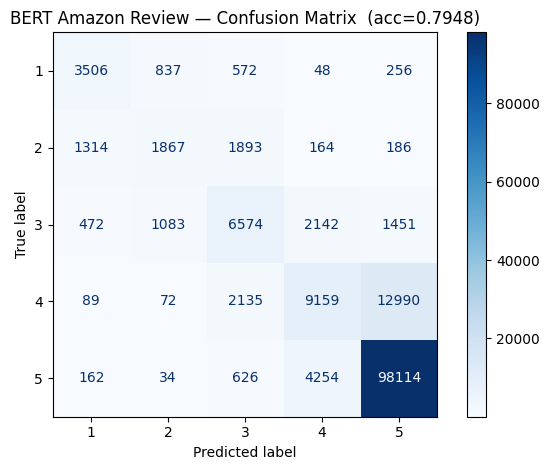

In [8]:
# ── Cell 8: results / confusion matrix ───────────────────────────────────────

import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from tqdm.auto import tqdm

best_path = os.path.join(CKPT_DIR, "best.pt")
last_path = os.path.join(CKPT_DIR, "last.pt")

# Try to download best.pt from Hugging Face Hub
if not os.path.exists(best_path) and HF_REPO_ID:
    try:
        from huggingface_hub import hf_hub_download
        best_path = hf_hub_download(
            repo_id=HF_REPO_ID,
            filename="checkpoints/best.pt",
            repo_type="model",
            force_download=True,
        )
        print("Loaded best.pt from Hugging Face Hub")
    except Exception as e:
        print("best.pt not found on Hub, using last.pt instead")
        best_path = last_path

# Final fallback
if not os.path.exists(best_path):
    best_path = last_path

trainer.load_checkpoint(best_path)

model.eval()
all_preds, all_labels = [], []

# How often to emit a log-panel line (visible in Kaggle logs)
LOG_EVERY = 200   # batches
n_batches = len(val_loader)

print(f"Starting evaluation: {n_batches} batches", flush=True)

with torch.no_grad():
    pbar = tqdm(val_loader, desc="Evaluating", unit="batch",
                dynamic_ncols=True, colour="green")
    for i, batch in enumerate(pbar, 1):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)

        preds = model(ids, attention_mask=mask).argmax(-1).cpu().tolist()
        all_preds  += preds
        all_labels += batch["label"].tolist()

        running_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
        pbar.set_postfix(acc=f"{running_acc:.4f}")

        # Periodic stdout flush — shows up in Kaggle log panel
        if i % LOG_EVERY == 0 or i == n_batches:
            print(f"  eval [{i:>5}/{n_batches}]  "
                  f"acc={running_acc:.4f}  "
                  f"samples={len(all_labels):,}", flush=True)

acc = accuracy_score(all_labels, all_preds)
print(f"\nValidation accuracy: {acc:.4f}  ({acc*100:.2f}%)")

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4])
disp = ConfusionMatrixDisplay(cm, display_labels=[1, 2, 3, 4, 5])
disp.plot(cmap="Blues")

plt.title(f"BERT Amazon Review — Confusion Matrix  (acc={acc:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()